# EMPCA PC1 Hypothesis Verification — Clean Notebook

This notebook is designed to verify the hypothesis that, under the training workflow used in your frequency-domain EMPCA study, the first EMPCA component (**PC1**) is the dominant signal direction under the chosen weighted metric, and may reduce to an optimal-filter-like direction in the appropriate regime.

This version is built around the cleaner `empca.py` implementation, while preserving the **same preprocessing logic** used in your earlier training notebook as closely as possible:
- baseline subtraction,
- shift-invariant frequency transform via `ti_rfft` when available,
- PSD-based or template²/PSD weighting,
- explicit verification metrics in the training domain.

The notebook is conservative:
- it does **not** assume the hypothesis is true,
- it compares multiple candidate reference directions,
- it distinguishes **heuristic checks** from **rigorous metric-based validation**.

## Notebook roadmap

1. Locate data, templates, PSD, and EMPCA implementations
2. Reproduce the preprocessing convention from the training notebook
3. Train a clean EMPCA model using `empca.py`
4. Build several reference directions
5. Compare PC1 to those references with the **same weighted inner product**
6. Test amplitude equivalence
7. Test physics-level performance proxies
8. Run robustness checks
9. Summarize what is and is not supported

In [1]:
import sys
from pathlib import Path
import json
import pickle
import math

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import h5py
except Exception as e:
    raise ImportError("This notebook requires h5py to load the trace HDF5 files.") from e

In [ ]:
# ----------------------------
# Locate implementations and data
# ----------------------------
SEARCH_ROOTS = [
    Path.cwd(),
    Path("/mnt/data"),
    Path.cwd() / "wk7/PC_interpretation",
    Path("/mnt/data/wk7/PC_interpretation"),
]

def existing(paths):
    return [Path(p) for p in paths if Path(p).exists()]

# Candidate clean EMPCA implementation
EMPCA_CANDIDATES = existing([
    Path("empca.py"),
    Path("/mnt/data/empca.py"),
])

if not EMPCA_CANDIDATES:
    raise FileNotFoundError("Could not find empca.py")

EMPCA_PY = EMPCA_CANDIDATES[0]
sys.path.insert(0, str(EMPCA_PY.parent))
import wk8.PC_interpretation.archive.empca as clean_empca

# Candidate optimized implementation only for ti_rfft helper if available
OPT_CANDIDATES = existing([
    Path("empca_TCY_optimized.py"),
    Path("/mnt/data/empca_TCY_optimized.py"),
])

HAS_OPT = False
if OPT_CANDIDATES:
    try:
        import importlib.util
        spec = importlib.util.spec_from_file_location("empca_opt", OPT_CANDIDATES[0])
        empca_opt = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(empca_opt)
        HAS_OPT = True
    except Exception as e:
        print("Warning: could not import optimized EMPCA helper file:", e)
        HAS_OPT = False

DATA_CANDIDATES = existing([
    "k_alpha_traces.h5",
    "/mnt/data/k_alpha_traces.h5",
    "wk7/PC_interpretation/k_alpha_traces.h5",
    "/mnt/data/wk7/PC_interpretation/k_alpha_traces.h5",
])
RQS_CANDIDATES = existing([
    "k_alpha_rqs.h5",
    "/mnt/data/k_alpha_rqs.h5",
    "wk7/PC_interpretation/k_alpha_rqs.h5",
    "/mnt/data/wk7/PC_interpretation/k_alpha_rqs.h5",
])
PSD_CANDIDATES = existing([
    "/ceph/dwong/delight/noise_psd_xray.npy",
    "noise_psd_xray.npy",
    "/mnt/data/noise_psd_xray.npy",
])
TEMPLATE_CANDIDATES = existing([
    "template_K_alpha_tight.npy",
    "/mnt/data/template_K_alpha_tight.npy",
    "wk7/PC_interpretation/template_K_alpha_tight.npy",
    "/mnt/data/wk7/PC_interpretation/template_K_alpha_tight.npy",
])
TRANSFORMED_TEMPLATE_CANDIDATES = existing([
    "/ceph/dwong/delight/transformed_template_K_alpha_tight.npy",
    "transformed_template_K_alpha_tight.npy",
    "/mnt/data/transformed_template_K_alpha_tight.npy",
    "wk7/PC_interpretation/transformed_template_K_alpha_tight.npy",
    "/mnt/data/wk7/PC_interpretation/transformed_template_K_alpha_tight.npy",
])

print("Using clean EMPCA:", EMPCA_PY)
print("Optimized helper available:", HAS_OPT)
print("Trace files:", DATA_CANDIDATES)
print("RQS files:", RQS_CANDIDATES)
print("PSD files:", PSD_CANDIDATES)
print("Template files:", TEMPLATE_CANDIDATES)
print("Transformed template files:", TRANSFORMED_TEMPLATE_CANDIDATES)

Using clean EMPCA: empca.py
Optimized helper available: False
Trace files: [PosixPath('k_alpha_traces.h5')]
RQS files: [PosixPath('k_alpha_rqs.h5')]
PSD files: [PosixPath('/ceph/dwong/delight/noise_psd_xray.npy')]
Template files: [PosixPath('template_K_alpha_tight.npy')]
Transformed template files: []


## Preprocessing helpers

The earlier training notebook used:
- baseline subtraction on the first `pretrigger` samples,
- `ti_rfft` as the preferred shift-invariant frequency transform.

We preserve that convention when possible. If `ti_rfft` is unavailable, we fall back to standard `rfft` and print that clearly.

In [3]:
def baseline_correct_per_trace(X_time, pretrigger=4000, method="mean"):
    X_time = np.asarray(X_time, dtype=np.float64)
    if X_time.ndim != 2:
        raise ValueError(f"X_time must be 2D; got shape {X_time.shape}")
    if not (1 <= pretrigger <= X_time.shape[1]):
        raise ValueError("pretrigger must be within [1, n_time]")
    pre = X_time[:, :pretrigger]
    if method == "mean":
        baseline = np.mean(pre, axis=1)
    elif method == "median":
        baseline = np.median(pre, axis=1)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    X0 = X_time - baseline[:, None]
    return X0, baseline

def to_shift_invariant_spectrum(X_time):
    X_time = np.asarray(X_time)
    if HAS_OPT and hasattr(empca_opt, "ti_rfft"):
        X_tilde = empca_opt.ti_rfft(X_time)
        transform_name = "ti_rfft"
    else:
        X_tilde = np.fft.rfft(X_time, axis=-1)
        transform_name = "numpy_rfft_fallback"
    X_tilde = np.asarray(X_tilde)
    if X_tilde.ndim == 1:
        X_tilde = X_tilde[None, :]
    return X_tilde, transform_name

def inverse_shift_invariant_spectrum(Xf, target_len=None):
    Xf = np.asarray(Xf)
    if Xf.ndim == 1:
        Xf = Xf[None, :]
    if HAS_OPT and hasattr(empca_opt, "ti_irfft"):
        if target_len is None:
            # ti_irfft uses padding count, not target length directly; when not known leave padding 0
            x = empca_opt.ti_irfft(Xf)
        else:
            n_freq = Xf.shape[-1]
            full_n_freq = target_len // 2 + 1
            padding = max(0, full_n_freq - n_freq)
            x = empca_opt.ti_irfft(Xf, padding=padding)
        inv_name = "ti_irfft"
    else:
        if target_len is None:
            target_len = 2 * (Xf.shape[-1] - 1)
        x = np.fft.irfft(Xf, n=target_len, axis=-1)
        inv_name = "numpy_irfft_fallback"
    x = np.asarray(x)
    if x.ndim == 1:
        x = x[None, :]
    return x, inv_name

def load_first_existing(candidates):
    if not candidates:
        return None
    return Path(candidates[0])

## Configuration

Adjust these flags if needed. Defaults are chosen to mirror the earlier training notebook closely while staying computationally manageable.

In [4]:
CFG = dict(
    pretrigger=4000,
    baseline_method="mean",
    use_subset=True,
    max_events=1000,
    nvec=2,
    niter=20,
    smooth=0,                  # start with no smoothing for the cleanest verification
    weight_mode="inverse_psd", # options: inverse_psd, snr2
    center_traces=False,       # optional robustness control
    rng_seed=1,
    compare_rank1=True,
)

print(json.dumps(CFG, indent=2))

{
  "pretrigger": 4000,
  "baseline_method": "mean",
  "use_subset": true,
  "max_events": 1000,
  "nvec": 2,
  "niter": 20,
  "smooth": 0,
  "weight_mode": "inverse_psd",
  "center_traces": false,
  "rng_seed": 1,
  "compare_rank1": true
}


## Load data

If the real trace files are found, the notebook uses them. Otherwise it falls back to a synthetic rank-1 test dataset so the verification machinery can still run end-to-end.

In [5]:
TRACE_H5 = load_first_existing(DATA_CANDIDATES)
RQS_H5 = load_first_existing(RQS_CANDIDATES)
PSD_PATH = load_first_existing(PSD_CANDIDATES)
TEMPLATE_PATH = load_first_existing(TEMPLATE_CANDIDATES)
TRANSFORMED_TEMPLATE_PATH = load_first_existing(TRANSFORMED_TEMPLATE_CANDIDATES)

use_real_data = TRACE_H5 is not None and PSD_PATH is not None

if use_real_data:
    with h5py.File(TRACE_H5, "r") as f:
        key = "traces" if "traces" in f else list(f.keys())[0]
        X_time = f[key][:].astype(np.float64)
    if CFG["use_subset"]:
        X_time = X_time[:CFG["max_events"]]

    rqs = None
    if RQS_H5 is not None:
        with h5py.File(RQS_H5, "r") as f:
            key = "rqs" if "rqs" in f else list(f.keys())[0]
            rqs = f[key][:]
            if CFG["use_subset"]:
                rqs = rqs[:CFG["max_events"]]

    psd_arr = np.load(PSD_PATH)
    psd = psd_arr[1] if (np.ndim(psd_arr) == 2 and psd_arr.shape[0] == 2) else psd_arr
    psd = np.asarray(psd, dtype=np.float64)

    template_t = None
    if TEMPLATE_PATH is not None:
        template_t = np.load(TEMPLATE_PATH).astype(np.float64)

    transformed_template = None
    if TRANSFORMED_TEMPLATE_PATH is not None:
        transformed_template = np.load(TRANSFORMED_TEMPLATE_PATH)
else:
    rng = np.random.default_rng(CFG["rng_seed"])
    n_events = 512
    n_time = 16384
    t = np.arange(n_time)
    template_t = np.exp(-0.5*((t-5200)/120.0)**2) - 0.35*np.exp(-0.5*((t-5600)/260.0)**2)
    amps = rng.uniform(0.5, 1.5, size=n_events)
    sigma = 1.0
    X_time = amps[:, None] * template_t[None, :] + rng.normal(0, sigma, size=(n_events, n_time))
    psd = np.ones(n_time//2 + 1, dtype=np.float64)
    transformed_template = None
    rqs = None

print("Using real data:", use_real_data)
print("X_time shape:", X_time.shape)
print("PSD shape:", psd.shape)
print("Template available:", template_t is not None)
print("Transformed template available:", transformed_template is not None)
print("RQS available:", rqs is not None)

Using real data: True
X_time shape: (1000, 32768)
PSD shape: (16385,)
Template available: True
Transformed template available: False
RQS available: True


## Apply preprocessing and prepare training domain

The core verification must be done in the **same domain where EMPCA was trained**.

In [6]:
X0, baselines = baseline_correct_per_trace(
    X_time,
    pretrigger=min(CFG["pretrigger"], X_time.shape[1]),
    method=CFG["baseline_method"],
)

if CFG["center_traces"]:
    X0 = X0 - np.mean(X0, axis=0, keepdims=True)

X_tilde, transform_name = to_shift_invariant_spectrum(X0)
n_events, n_freq = X_tilde.shape

if len(psd) < n_freq:
    raise ValueError(f"PSD length mismatch: PSD has {len(psd)} bins but transformed data has {n_freq}.")
psd = psd[:n_freq]

if transformed_template is not None:
    template_f = np.asarray(transformed_template)[:n_freq]
elif template_t is not None:
    template_f, _ = to_shift_invariant_spectrum(template_t[None, :])
    template_f = np.asarray(template_f[0])[:n_freq]
else:
    template_f = None

print("Transform used:", transform_name)
print("Training domain shape:", X_tilde.shape, X_tilde.dtype)
print("Baseline method:", CFG["baseline_method"])
print("Centered traces:", CFG["center_traces"])
print("n_freq:", n_freq)

Transform used: numpy_rfft_fallback
Training domain shape: (1000, 16385) complex128
Baseline method: mean
Centered traces: False
n_freq: 16385


## Build weights

Two candidate metric choices are supported:

- `inverse_psd`: \(w(f) = 1 / \mathrm{PSD}(f)\)
- `snr2`: \(w(f) = |T(f)|^2 / \mathrm{PSD}(f)\)

For the cleanest theoretical test of OF equivalence, start with `inverse_psd`.

In [7]:
eps = 1e-18
if CFG["weight_mode"] == "inverse_psd":
    w = 1.0 / np.maximum(psd, eps)
elif CFG["weight_mode"] == "snr2":
    if template_f is None:
        raise ValueError("snr2 mode requested but no template is available.")
    w = (np.abs(template_f) ** 2) / np.maximum(psd, eps)
else:
    raise ValueError("Unknown weight_mode")

w = np.asarray(w, dtype=np.float64)
print("Weight mode:", CFG["weight_mode"])
print("Weight shape:", w.shape)
print("Weight min/max:", float(np.min(w)), float(np.max(w)))

Weight mode: inverse_psd
Weight shape: (16385,)
Weight min/max: 727.770933918662 582032.7218170777


## Train clean EMPCA model

This uses the simpler `empca.py` implementation.  
Important note: `empca.py` expects `weights` with shape `(nobs, nvar)`, so we tile the diagonal weight vector over observations.

In [8]:
weights_2d = np.tile(w[None, :], (n_events, 1))

model = clean_empca.empca(
    X_tilde,
    weights=weights_2d,
    niter=CFG["niter"],
    nvec=CFG["nvec"],
    smooth=CFG["smooth"],
    randseed=CFG["rng_seed"],
    silent=False,
)

eigvec = np.asarray(model.eigvec)
coeff = np.asarray(model.coeff)
pc1 = eigvec[0]

print("eigvec shape:", eigvec.shape)
print("coeff shape:", coeff.shape)
print("PC1 dtype:", pc1.dtype)
print("R2(all):", model.R2())
print("rchi2:", model.rchi2())

/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:256: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x = np.linalg.lstsq(A, b)[0]
/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  self.coeff[i] = _solve(self.eigvec.T, self.data[i], self.weights[i])


       iter        R2             rchi2


/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  self.eigvec[k, j] = x.dot(cw) / c.dot(cw)


EMPCA  1/20       0.00019752 1089189039266119.00000000


/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:309: ComplexWarning: Casting complex values to real discards the imaginary part
  print('EMPCA %2d/%2d  %15.8f %15.8f' % \


EMPCA  2/20       0.92859156 -163142230103678.87500000
EMPCA  3/20       0.92859158 -163142618462048.18750000
EMPCA  4/20       0.92859158 -163142632799872.15625000
EMPCA  5/20       0.92859158 -163142632847530.93750000
EMPCA  6/20       0.92859158 -163142632847893.09375000
EMPCA  7/20       0.92859158 -163142632847896.62500000
EMPCA  8/20       0.92859158 -163142632847896.34375000
EMPCA  9/20       0.92859158 -163142632847896.43750000
EMPCA 10/20       0.92859158 -163142632847896.25000000
EMPCA 11/20       0.92859158 -163142632847896.28125000
EMPCA 12/20       0.92859158 -163142632847896.34375000
EMPCA 13/20       0.92859158 -163142632847896.34375000
EMPCA 14/20       0.92859158 -163142632847896.34375000
EMPCA 15/20       0.92859158 -163142632847896.34375000
EMPCA 16/20       0.92859158 -163142632847896.34375000
EMPCA 17/20       0.92859158 -163142632847896.34375000
EMPCA 18/20       0.92859158 -163142632847896.34375000
EMPCA 19/20       0.92859158 -163142632847896.34375000
EMPCA 20/2

## Physics interpretation of the learned PC1

For this implementation, the first component is obtained by alternating:
1. weighted least-squares coefficient solve,
2. weighted eigenvector update,
3. optional smoothing,
4. orthonormalization,
5. iteration.

So PC1 should be interpreted as a **dominant empirical signal mode under the chosen weighted reconstruction metric**.  
The hypothesis under test is whether this mode aligns with an OF-like reference direction in the appropriate regime.

## Build candidate reference directions

We compare PC1 to several references:

- **A. OF direction:** \(T/\mathrm{PSD}\)
- **B1. Mean in transformed domain:** average of the training traces after transform
- **B2. Transform of the mean time-domain trace**
- **C. Weighted mean heuristic:** mean of \(w \cdot X\)
- **D. Metric-implied reference for `snr2`:** \(w \cdot T\) (heuristic diagnostic)

Only the metric-consistent comparison is rigorous; the others are diagnostics.

In [9]:
mean_f_post = np.mean(X_tilde, axis=0)
mean_t_pre = np.mean(X0, axis=0)
mean_f_pre, _ = to_shift_invariant_spectrum(mean_t_pre[None, :])
mean_f_pre = mean_f_pre[0][:n_freq]

references = {}

if template_f is not None:
    references["A_OF_T_over_PSD"] = template_f / np.maximum(psd, eps)
    references["D_metric_times_template"] = w * template_f

references["B1_mean_freq_post_transform"] = mean_f_post
references["B2_mean_time_then_transform"] = mean_f_pre
references["C_weighted_mean_heuristic"] = np.mean(X_tilde * w[None, :], axis=0)

print("Reference names:", list(references.keys()))

Reference names: ['A_OF_T_over_PSD', 'D_metric_times_template', 'B1_mean_freq_post_transform', 'B2_mean_time_then_transform', 'C_weighted_mean_heuristic']


## Weighted comparison utilities

These are the primary verification tools.  
They are:
- complex-aware,
- scale-invariant,
- phase-invariant,
- matched to the training metric.

In [10]:
def weighted_inner(u, v, w):
    u = np.asarray(u)
    v = np.asarray(v)
    w = np.asarray(w)
    return np.vdot(u, w * v)

def weighted_norm(u, w):
    val = np.real(weighted_inner(u, u, w))
    return np.sqrt(max(val, 0.0))

def weighted_cosine(u, v, w):
    den = weighted_norm(u, w) * weighted_norm(v, w)
    if den == 0:
        return np.nan
    return float(np.abs(weighted_inner(u, v, w)) / den)

def best_fit_alpha(u, v, w):
    # alpha minimizing ||u - alpha v||_W^2
    den = weighted_inner(v, v, w)
    if np.abs(den) == 0:
        return np.nan + 1j*np.nan
    return weighted_inner(v, u, w) / den

def aligned_residual(u, v, w):
    alpha = best_fit_alpha(u, v, w)
    r = u - alpha * v
    nu = weighted_norm(u, w)
    if nu == 0:
        return np.nan, alpha
    return float(weighted_norm(r, w) / nu), alpha

def principal_angle_deg(u, v, w):
    c = weighted_cosine(u, v, w)
    if np.isnan(c):
        return np.nan
    return float(np.degrees(np.arccos(np.clip(c, -1.0, 1.0))))

## Directional verification

This is the core test of the hypothesis.

Interpretation:
- cosine close to 1 → same weighted direction
- principal angle close to 0° → same 1D subspace
- relative residual small → same up to a complex scalar

In [11]:
rows = []
for name, ref in references.items():
    cosw = weighted_cosine(pc1, ref, w)
    ang = principal_angle_deg(pc1, ref, w)
    resid, alpha = aligned_residual(pc1, ref, w)
    rows.append(dict(
        reference=name,
        cosine_w=cosw,
        principal_angle_deg=ang,
        rel_residual=resid,
        alpha_abs=float(np.abs(alpha)),
        alpha_phase_deg=float(np.degrees(np.angle(alpha))),
    ))

if pd is not None:
    results_df = pd.DataFrame(rows).sort_values(["cosine_w", "rel_residual"], ascending=[False, True]).reset_index(drop=True)
    display(results_df)
else:
    results_df = rows
    for r in rows:
        print(r)

best_reference = results_df.iloc[0]["reference"] if pd is not None else sorted(rows, key=lambda r: (-r["cosine_w"], r["rel_residual"]))[0]["reference"]
print("Best directional match:", best_reference)

,reference,cosine_w,principal_angle_deg,rel_residual,alpha_abs,alpha_phase_deg
0,B1_mean_freq_post_transform,0.940977,19.783743,0.338471,5.391756e-09,-1.578726
1,B2_mean_time_then_transform,0.940977,19.783743,0.338471,5.391756e-09,-1.578726
2,A_OF_T_over_PSD,0.303466,72.334076,0.952842,6.095411e-09,-0.804317
3,D_metric_times_template,0.303466,72.334076,0.952842,6.095411e-09,-0.804317
4,C_weighted_mean_heuristic,0.292275,73.005773,0.956334,5.655174e-13,-0.834555


Best directional match: B1_mean_freq_post_transform


## Visual comparison after optimal complex alignment

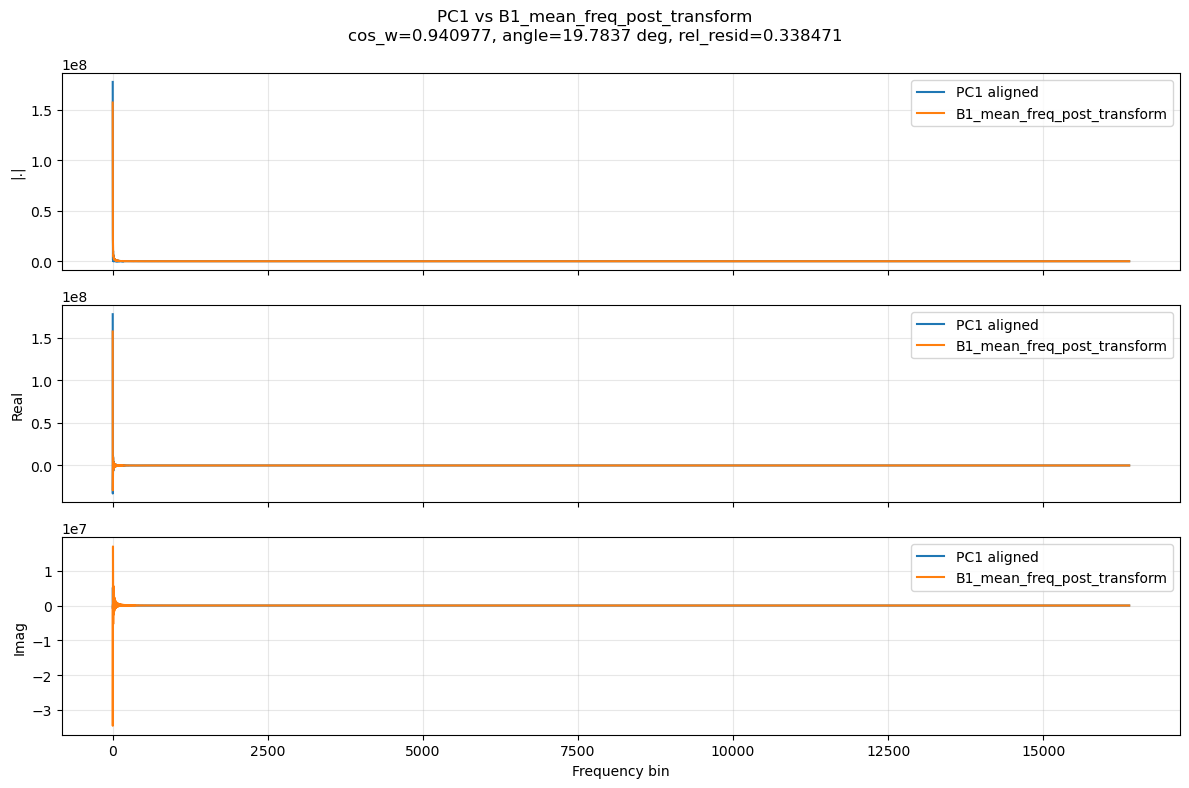

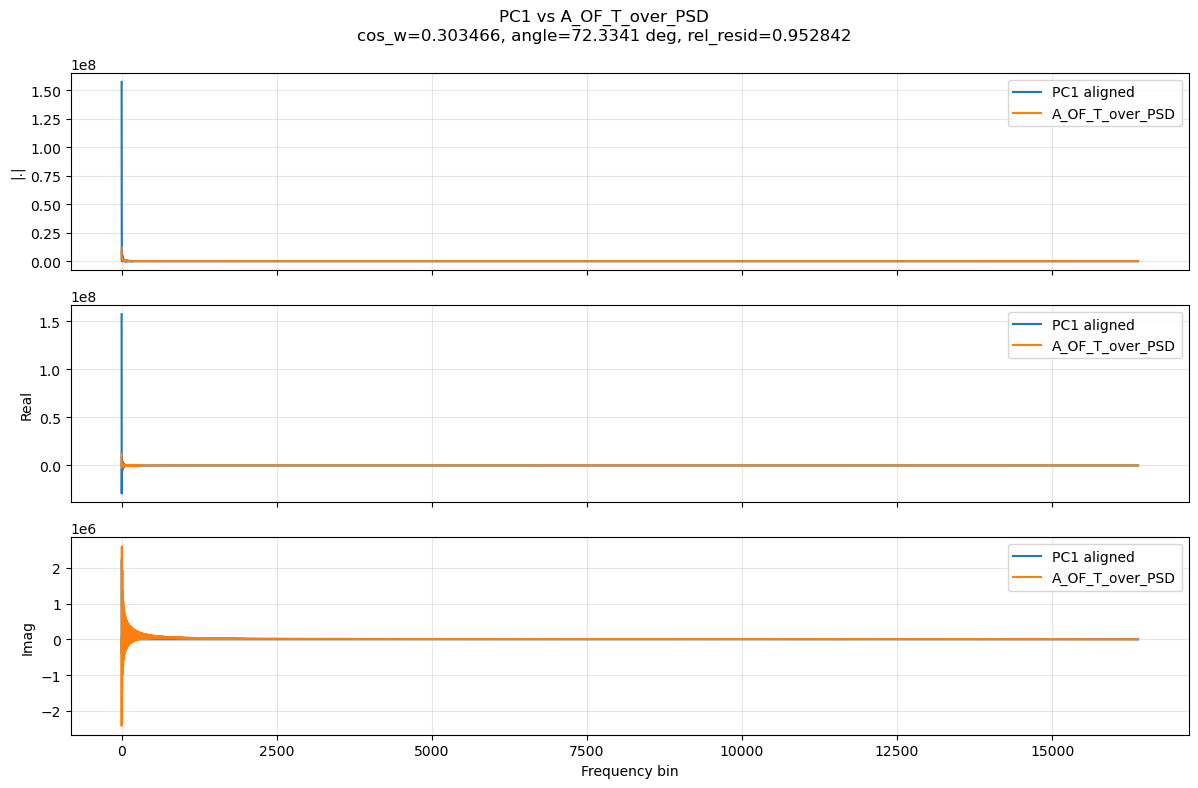

In [12]:
def align_to_reference(u, v, w):
    alpha = best_fit_alpha(u, v, w)
    if np.abs(alpha) == 0 or np.isnan(np.abs(alpha)):
        return u.copy(), alpha
    return u / alpha, alpha

top_refs = [best_reference]
if "A_OF_T_over_PSD" in references and best_reference != "A_OF_T_over_PSD":
    top_refs.append("A_OF_T_over_PSD")
if "B1_mean_freq_post_transform" in references and best_reference != "B1_mean_freq_post_transform":
    top_refs.append("B1_mean_freq_post_transform")

for ref_name in top_refs:
    ref = references[ref_name]
    pc1_aligned, alpha = align_to_reference(pc1, ref, w)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(np.abs(pc1_aligned), label="PC1 aligned")
    axes[0].plot(np.abs(ref), label=ref_name)
    axes[0].set_ylabel("|.|")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(np.real(pc1_aligned), label="PC1 aligned")
    axes[1].plot(np.real(ref), label=ref_name)
    axes[1].set_ylabel("Real")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(np.imag(pc1_aligned), label="PC1 aligned")
    axes[2].plot(np.imag(ref), label=ref_name)
    axes[2].set_ylabel("Imag")
    axes[2].set_xlabel("Frequency bin")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    cosw = weighted_cosine(pc1, ref, w)
    ang = principal_angle_deg(pc1, ref, w)
    resid, _ = aligned_residual(pc1, ref, w)
    fig.suptitle(f"PC1 vs {ref_name}\ncos_w={cosw:.6f}, angle={ang:.4f} deg, rel_resid={resid:.6f}")
    plt.tight_layout()
    plt.show()

## Diagnostic time-domain view

These plots are for intuition only.  
The rigorous verification is the weighted comparison in the training domain.

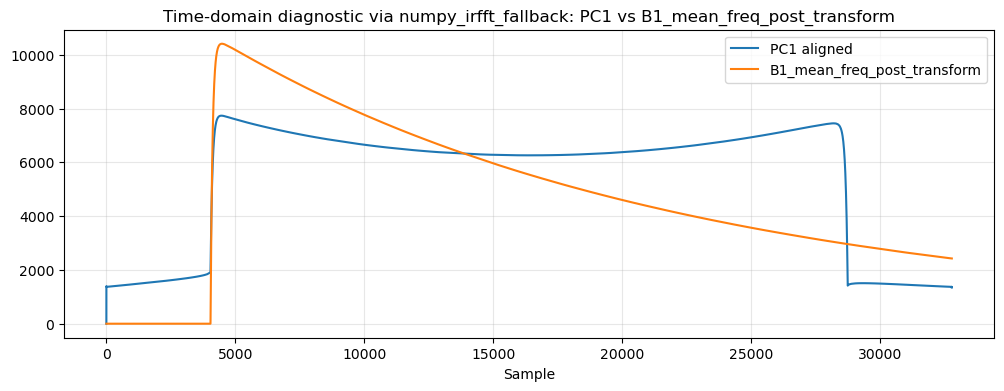

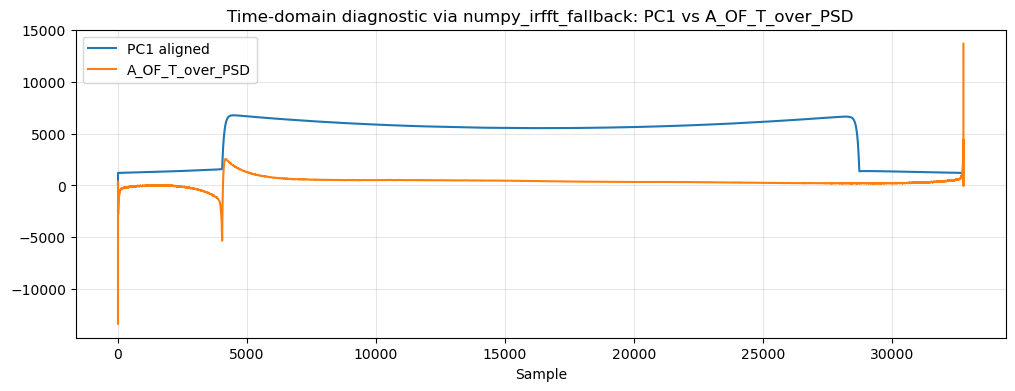

In [13]:
if template_t is not None:
    for ref_name in top_refs:
        ref = references[ref_name]
        pc1_aligned, _ = align_to_reference(pc1, ref, w)
        pc1_t, inv_name = inverse_shift_invariant_spectrum(pc1_aligned, target_len=X0.shape[1])
        ref_t, _ = inverse_shift_invariant_spectrum(ref, target_len=X0.shape[1])

        plt.figure(figsize=(12, 4))
        plt.plot(np.asarray(pc1_t).ravel(), label="PC1 aligned")
        plt.plot(np.asarray(ref_t).ravel(), label=ref_name)
        plt.title(f"Time-domain diagnostic via {inv_name}: PC1 vs {ref_name}")
        plt.xlabel("Sample")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

## Amplitude-equivalence test

Even if two directions are not exactly equal, they may still extract highly correlated amplitude information.

We compare:
- EMPCA rank-1 projection onto PC1
- reference projection onto a chosen comparison direction

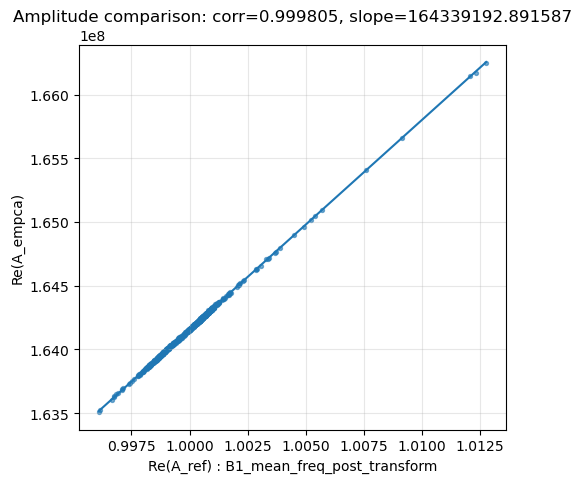

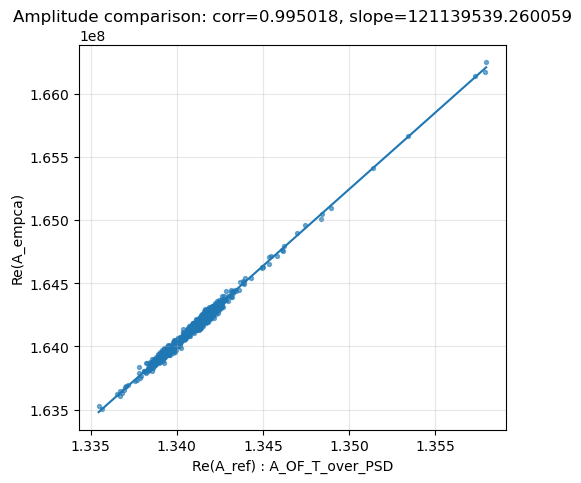

,reference,corr_real,slope_real,intercept_real,empca_std_real,ref_std_real
0,B1_mean_freq_post_transform,0.999805,1.643392e+08,-1.809358e+05,221956.193192,0.001350
1,A_OF_T_over_PSD,0.995018,1.211395e+08,1.704067e+06,221956.193192,0.001823


In [14]:
def project_amplitude(Xf, vec, w):
    # amplitude-like scalar in the weighted metric, normalized by self-overlap
    den = weighted_inner(vec, vec, w)
    if np.abs(den) == 0:
        raise ValueError("Reference vector has zero weighted norm.")
    return np.array([weighted_inner(vec, x, w) / den for x in Xf])

A_empca = project_amplitude(X_tilde, pc1, w)

amp_rows = []
for ref_name in top_refs:
    ref = references[ref_name]
    A_ref = project_amplitude(X_tilde, ref, w)

    # regression in real part as a simple diagnostic
    xr = np.real(A_ref)
    yr = np.real(A_empca)
    slope, intercept = np.polyfit(xr, yr, 1)
    corr = np.corrcoef(xr, yr)[0, 1]

    amp_rows.append(dict(
        reference=ref_name,
        corr_real=float(corr),
        slope_real=float(slope),
        intercept_real=float(intercept),
        empca_std_real=float(np.std(np.real(A_empca))),
        ref_std_real=float(np.std(np.real(A_ref))),
    ))

    plt.figure(figsize=(5.5, 5))
    plt.scatter(xr, yr, s=8, alpha=0.6)
    xx = np.linspace(np.min(xr), np.max(xr), 200)
    plt.plot(xx, slope*xx + intercept)
    plt.xlabel(f"Re(A_ref) : {ref_name}")
    plt.ylabel("Re(A_empca)")
    plt.title(f"Amplitude comparison: corr={corr:.6f}, slope={slope:.6f}")
    plt.grid(alpha=0.3)
    plt.show()

if pd is not None:
    amp_df = pd.DataFrame(amp_rows)
    display(amp_df)
else:
    for r in amp_rows:
        print(r)

## Noise / signal proxy checks

This section gives a first physics-level diagnostic.
- On real data, this is only a proxy unless you have clean labels or injections.
- On synthetic data, we can directly compare against the known amplitudes.

In [15]:
if use_real_data:
    # Use the lowest-amplitude quantile of EMPCA projection as a rough noise-like subset
    ar = np.real(A_empca)
    lo = np.quantile(np.abs(ar), 0.2)
    noise_mask = np.abs(ar) <= lo
    signal_mask = np.abs(ar) > np.quantile(np.abs(ar), 0.8)

    print("Proxy noise count:", int(np.sum(noise_mask)))
    print("Proxy signal count:", int(np.sum(signal_mask)))

    proxy_rows = []
    for ref_name in top_refs:
        ref = references[ref_name]
        A_ref = np.real(project_amplitude(X_tilde, ref, w))
        A_e = np.real(A_empca)

        sigma_empca = np.std(A_e[noise_mask]) if np.sum(noise_mask) > 5 else np.nan
        sigma_ref = np.std(A_ref[noise_mask]) if np.sum(noise_mask) > 5 else np.nan

        mu_empca_sig = np.mean(A_e[signal_mask]) if np.sum(signal_mask) > 5 else np.nan
        mu_ref_sig = np.mean(A_ref[signal_mask]) if np.sum(signal_mask) > 5 else np.nan

        dprime_empca = (mu_empca_sig - np.mean(A_e[noise_mask])) / sigma_empca if sigma_empca and sigma_empca > 0 else np.nan
        dprime_ref = (mu_ref_sig - np.mean(A_ref[noise_mask])) / sigma_ref if sigma_ref and sigma_ref > 0 else np.nan

        proxy_rows.append(dict(
            reference=ref_name,
            empca_noise_std=sigma_empca,
            ref_noise_std=sigma_ref,
            empca_dprime_proxy=dprime_empca,
            ref_dprime_proxy=dprime_ref,
        ))

    if pd is not None:
        proxy_df = pd.DataFrame(proxy_rows)
        display(proxy_df)
    else:
        for r in proxy_rows:
            print(r)
else:
    true_amp = amps
    plt.figure(figsize=(6, 4))
    plt.scatter(true_amp, np.real(A_empca), s=8, alpha=0.6)
    slope, intercept = np.polyfit(true_amp, np.real(A_empca), 1)
    xx = np.linspace(np.min(true_amp), np.max(true_amp), 200)
    plt.plot(xx, slope*xx + intercept)
    plt.xlabel("True amplitude")
    plt.ylabel("Re(A_empca)")
    plt.title(f"Synthetic linearity: slope={slope:.6f}")
    plt.grid(alpha=0.3)
    plt.show()

Proxy noise count: 200
Proxy signal count: 200


,reference,empca_noise_std,ref_noise_std,empca_dprime_proxy,ref_dprime_proxy
0,B1_mean_freq_post_transform,77952.243922,0.000476,6.544866,6.486136
1,A_OF_T_over_PSD,77952.243922,0.000679,6.544866,6.075433


## Robustness checks

At minimum:
- rank-1 training
- optional centering
- optional smoothing

These checks help distinguish a real conclusion from an artifact of one configuration.

In [16]:
robustness_rows = []

for nvec_test, smooth_test in [(1, 0), (1, 7 if CFG["smooth"] == 0 else CFG["smooth"]), (CFG["nvec"], CFG["smooth"])]:
    try:
        model_rb = clean_empca.empca(
            X_tilde,
            weights=weights_2d,
            niter=min(CFG["niter"], 12),
            nvec=nvec_test,
            smooth=smooth_test,
            randseed=CFG["rng_seed"],
            silent=True,
        )
        pc1_rb = np.asarray(model_rb.eigvec)[0]
        ref = references[best_reference]
        cosw = weighted_cosine(pc1_rb, ref, w)
        ang = principal_angle_deg(pc1_rb, ref, w)
        resid, _ = aligned_residual(pc1_rb, ref, w)
        robustness_rows.append(dict(
            nvec=nvec_test,
            smooth=smooth_test,
            cosine_w=cosw,
            principal_angle_deg=ang,
            rel_residual=resid,
        ))
    except Exception as e:
        robustness_rows.append(dict(
            nvec=nvec_test,
            smooth=smooth_test,
            cosine_w=np.nan,
            principal_angle_deg=np.nan,
            rel_residual=np.nan,
            error=str(e),
        ))

if pd is not None:
    robustness_df = pd.DataFrame(robustness_rows)
    display(robustness_df)
else:
    for r in robustness_rows:
        print(r)

/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:256: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x = np.linalg.lstsq(A, b)[0]
/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  self.coeff[i] = _solve(self.eigvec.T, self.data[i], self.weights[i])
/home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/empca.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  self.eigvec[k, j] = x.dot(cw) / c.dot(cw)


,nvec,smooth,cosine_w,principal_angle_deg,rel_residual
0,1,0,0.940977,19.783743,0.338471
1,1,7,0.629219,51.007443,0.777228
2,2,0,0.940977,19.783743,0.338471


## Verification criteria

Practical criteria for a strong equivalence claim:

- weighted cosine similarity close to 1
- principal angle close to 0°
- aligned residual much smaller than 1
- amplitude correlation close to 1
- no clear degradation in noise proxy / resolution proxy
- robustness under small changes such as rank-1 or smoothing choice

If these are **not** met, the safer interpretation is that PC1 is an empirical dominant mode, not a verified OF-equivalent direction.

In [17]:
# Final compact summary
def get_row(df, ref_name):
    if pd is not None:
        rr = df[df["reference"] == ref_name]
        if len(rr) == 0:
            return None
        return rr.iloc[0].to_dict()
    return None

best_row = get_row(results_df, best_reference) if pd is not None else None
of_row = get_row(results_df, "A_OF_T_over_PSD") if pd is not None and "A_OF_T_over_PSD" in references else None

summary = {
    "best_reference": best_reference,
    "best_reference_metrics": best_row,
    "of_reference_metrics": of_row,
    "weight_mode": CFG["weight_mode"],
    "transform": transform_name,
    "center_traces": CFG["center_traces"],
    "smooth": CFG["smooth"],
    "nvec": CFG["nvec"],
}

print(json.dumps(summary, indent=2, default=lambda x: None))

{
  "best_reference": "B1_mean_freq_post_transform",
  "best_reference_metrics": {
    "reference": "B1_mean_freq_post_transform",
    "cosine_w": 0.9409768432523032,
    "principal_angle_deg": 19.783743119599087,
    "rel_residual": 0.33847094478393547,
    "alpha_abs": 5.391756316659889e-09,
    "alpha_phase_deg": -1.5787261472665601
  },
  "of_reference_metrics": {
    "reference": "A_OF_T_over_PSD",
    "cosine_w": 0.30346642361944054,
    "principal_angle_deg": 72.3340759523704,
    "rel_residual": 0.9528421326408827,
    "alpha_abs": 6.095410650440984e-09,
    "alpha_phase_deg": -0.8043171301297275
  },
  "weight_mode": "inverse_psd",
  "transform": "numpy_rfft_fallback",
  "center_traces": false,
  "smooth": 0,
  "nvec": 2
}


## Final interpretation template

Use the actual numbers above to state the conclusion.

Suggested wording:

- **If OF wins strongly:**  
  “Under the current preprocessing and inverse-PSD metric, PC1 is consistent with the OF direction up to complex scale/phase.”

- **If a mean-like reference wins strongly:**  
  “Under the current preprocessing and metric, PC1 is better interpreted as the dominant empirical waveform mode than as the OF direction.”

- **If results are mixed:**  
  “PC1 captures related amplitude information, but directional equivalence to OF is not yet established.”

This notebook is intentionally set up so the conclusion follows from the metrics, not from prior expectation.